In [20]:
import numpy as np 
import pandas as pd  
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [21]:
print(os.listdir("/kaggle/input"))

['datasets']


In [22]:
print(os.listdir("/kaggle/input/datasets"))

['snmahsa']


In [23]:
print(os.listdir("/kaggle/input/datasets/snmahsa"))

['human-images-dataset-men-and-women']


In [24]:
print(os.listdir("/kaggle/input/datasets/snmahsa/human-images-dataset-men-and-women"))

['gender_dataset']


In [25]:
data_path = "/kaggle/input/datasets/snmahsa/human-images-dataset-men-and-women/gender_dataset"

In [26]:
print(data_path)

/kaggle/input/datasets/snmahsa/human-images-dataset-men-and-women/gender_dataset


In [27]:
classes = os.listdir(data_path)
print(classes)

['men', 'women']


In [28]:
for cls in classes:
    count = len(os.listdir(data_path + '/' + cls))
    print(cls , ":" , count)

men : 833
women : 835


In [29]:
print(len(classes))

2


In [30]:
file_name = os.listdir(os.path.join(data_path, "men"))[0]
image_path = os.path.join(data_path, "men", file_name)
print(file_name)

623.jpg


In [31]:
print(image_path)

/kaggle/input/datasets/snmahsa/human-images-dataset-men-and-women/gender_dataset/men/623.jpg


In [32]:
import cv2
img = cv2.imread(image_path)

if img is None:
    print("Image failed to load:", image_path)
else:
    print("Image shape:", img.shape)

Image shape: (5622, 4516, 3)


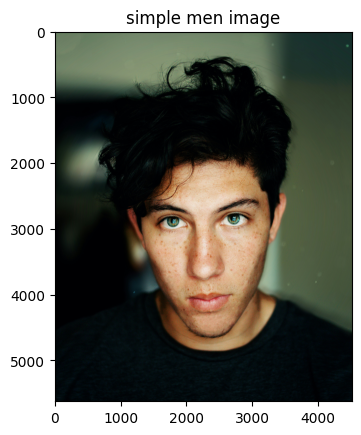

In [33]:
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title("simple men image")
plt.show()

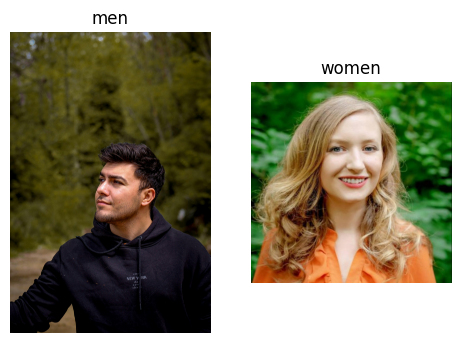

In [34]:
plt.figure(figsize=(15, 4))

for i, cls in enumerate(classes):
    file  = os.listdir(data_path + '/' + cls)[2]
    path  = data_path + '/' + cls + '/' + file
    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.subplot(1, 5, i+1)
    plt.imshow(image)
    plt.title(cls)
    plt.axis('off')

plt.show()

In [35]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# generator with augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Validation generator (no augmentation)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Training data
train_data = train_datagen.flow_from_directory(
    data_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training',
    shuffle=True,
    interpolation='bilinear'
)


# Validation data
val_data = val_datagen.flow_from_directory(
    data_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    interpolation='bilinear'
)
# Check
print("Class indices:", train_data.class_indices)
print("Image shape:", train_data.image_shape)

Found 1335 images belonging to 2 classes.
Found 333 images belonging to 2 classes.
Class indices: {'men': 0, 'women': 1}
Image shape: (224, 224, 3)


In [36]:
print('Train images:', train_data.samples)
print('Train images:', val_data.samples)


Train images: 1335
Train images: 333


In [37]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Load MobileNetV2 pretrained on ImageNet (without top layers)
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model initially
base_model.trainable = False

# Build custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,624,065 (10.01 MB)

 Trainable params: 363,521 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [38]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

# Phase 1: Train only the head (base frozen)
print("=== Phase 1: Training Head Only ===")
history1 = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    steps_per_epoch=train_data.samples // train_data.batch_size,
    validation_steps=val_data.samples // val_data.batch_size,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Phase 2: Fine-tune last 30 layers of MobileNetV2
print("\n=== Phase 2: Fine-Tuning ===")
base_model.trainable = True

# Freeze all layers except last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Re-compile with lower LR for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop2 = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

reduce_lr2 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-8,
    verbose=1
)

history2 = model.fit(
    train_data,
    epochs=20,
    validation_data=val_data,
    steps_per_epoch=train_data.samples // train_data.batch_size,
    validation_steps=val_data.samples // val_data.batch_size,
    callbacks=[early_stop2, reduce_lr2],
    verbose=1
)

=== Phase 1: Training Head Only ===
Epoch 1/10


2026-03-01 07:40:30.105068: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 07:40:30.243504: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


17/41 ━━━━━━━━━━━━━━━━━━━━ 1:03 3s/step - accuracy: 0.6706 - loss: 0.6235

2026-03-01 07:41:26.293590: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 07:41:26.429946: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


41/41 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.7573 - loss: 0.4923 - val_accuracy: 0.9219 - val_loss: 0.2201 - learning_rate: 0.0010
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 167ms/step - accuracy: 0.9375 - loss: 0.1823 - val_accuracy: 0.9312 - val_loss: 0.2155 - learning_rate: 0.0010
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 108s 3s/step - accuracy: 0.9180 - loss: 0.2186 - val_accuracy: 0.9406 - val_loss: 0.1976 - learning_rate: 0.0010
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 169ms/step - accuracy: 0.9688 - loss: 0.1850 - val_accuracy: 0.9344 - val_loss: 0.2053 - learning_rate: 0.0010
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 103s 3s/step - accuracy: 0.9394 - loss: 0.1749 - val_accuracy: 0.9469 - val_loss: 0.1707 - learning_rate: 0.0010
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 166ms/step - accuracy: 0.8750 - loss: 0.3594 - val_accuracy: 0.9469 - val_loss: 0.1726 - learning_rate: 0.0010
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9555 - loss: 0.1157
Epoch 7: ReduceLROn

In [39]:
model.save('/kaggle/working/gender_classifier.keras')

In [40]:
model.save('/kaggle/working/gender_classifier.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


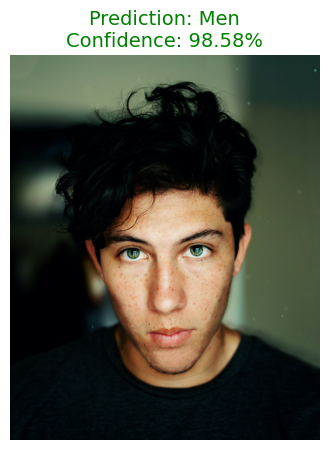

Prediction : Men
Confidence : 98.58%
Raw Score  : 0.0142


('Men', np.float32(98.58009))

In [44]:

import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

def predict_gender(image_path, model):
    # Image load aur preprocess
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)  # batch dimension add
    
    # Prediction
    pred = model.predict(img_input)[0][0]
    
    # Class decide  
    if pred >= 0.5:
        label = "Women"
        confidence = pred * 100
    else:
        label = "Men"
        confidence = (1 - pred) * 100
    
    # Show image with result
    plt.figure(figsize=(5, 5))
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {label}\nConfidence: {confidence:.2f}%", fontsize=14, color='green')
    plt.axis('off')
    plt.show()
    
    print(f"Prediction : {label}")
    print(f"Confidence : {confidence:.2f}%")
    print(f"Raw Score  : {pred:.4f}")
    
    return label, confidence

# Test 
image_path = "/kaggle/input/datasets/snmahsa/human-images-dataset-men-and-women/gender_dataset/men/623.jpg"
predict_gender(image_path, model)

11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 647ms/step
Classification Report:
              precision    recall  f1-score   support

         Men       0.94      0.97      0.95       166
       Women       0.97      0.93      0.95       167

    accuracy                           0.95       333
   macro avg       0.95      0.95      0.95       333
weighted avg       0.95      0.95      0.95       333



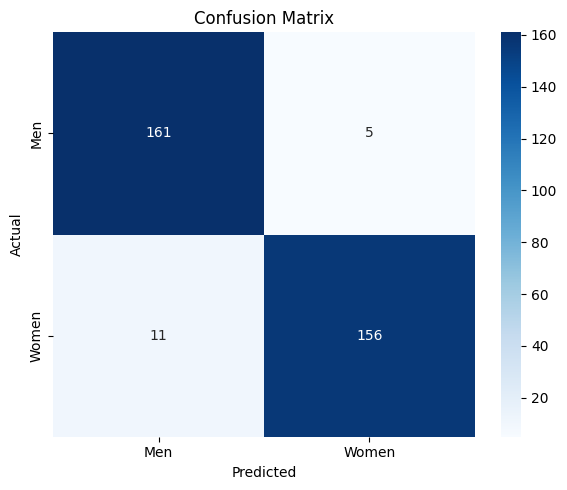

In [45]:

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predictions lao
val_data.reset()
y_pred_probs = model.predict(val_data, verbose=1)
y_pred = (y_pred_probs >= 0.5).astype(int).flatten()
y_true = val_data.classes

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Men', 'Women']))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Men', 'Women'],
            yticklabels=['Men', 'Women'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

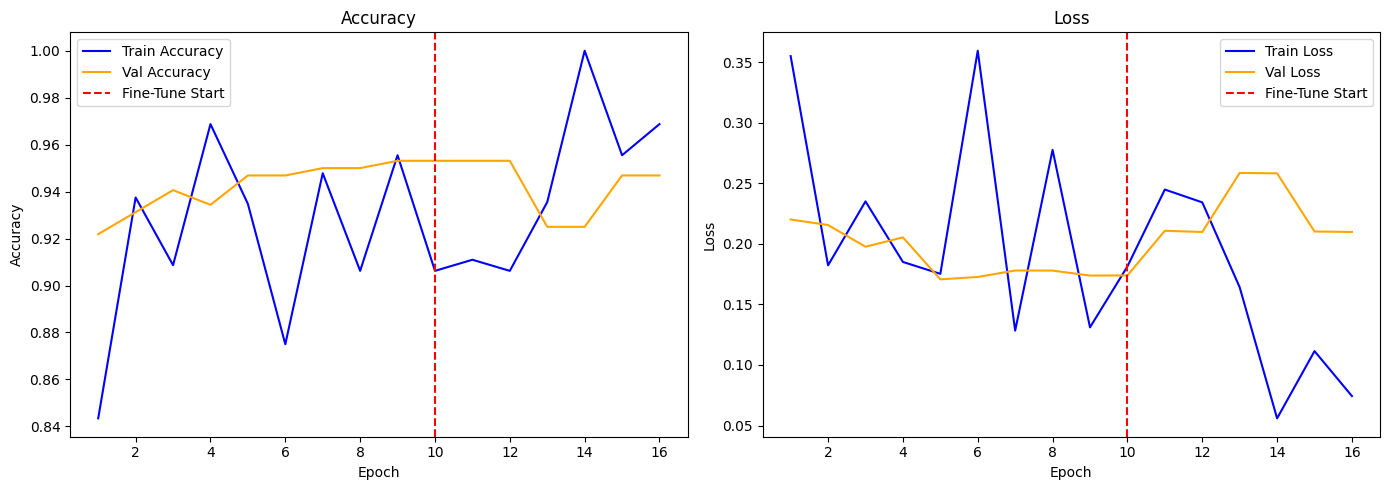

In [46]:

acc1 = history1.history['accuracy']
val_acc1 = history1.history['val_accuracy']
acc2 = history2.history['accuracy']
val_acc2 = history2.history['val_accuracy']

loss1 = history1.history['loss']
val_loss1 = history1.history['val_loss']
loss2 = history2.history['loss']
val_loss2 = history2.history['val_loss']

all_acc = acc1 + acc2
all_val_acc = val_acc1 + val_acc2
all_loss = loss1 + loss2
all_val_loss = val_loss1 + val_loss2

epochs_range = range(1, len(all_acc) + 1)

plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, all_acc, label='Train Accuracy', color='blue')
plt.plot(epochs_range, all_val_acc, label='Val Accuracy', color='orange')
plt.axvline(x=len(acc1), color='red', linestyle='--', label='Fine-Tune Start')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, all_loss, label='Train Loss', color='blue')
plt.plot(epochs_range, all_val_loss, label='Val Loss', color='orange')
plt.axvline(x=len(loss1), color='red', linestyle='--', label='Fine-Tune Start')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()